In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
#!mkdir -p /content/butterfly_dataset

In [ ]:
#!cp -r "/content/drive/MyDrive/Datasets/Image Dataset/data" /content/butterfly_dataset/

In [10]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import os
import sklearn
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import PIL
from PIL import Image
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
import joblib

In [25]:
print("Pandas Version:", pd.__version__)
print("Scikit-Learn Version", sklearn.__version__)
print("Tensorflow Version", tf.__version__)
print("PIL Version:", PIL.__version__)
print("Seaborn Version", sns.__version__)
print("Joblib Version:", joblib.__version__)

Pandas Version: 2.2.2
Scikit-Learn Version 1.6.1
Tensorflow Version 2.20.0
PIL Version: 11.3.0
Seaborn Version 0.13.2
Joblib Version: 1.5.3


In [24]:
# Colab local disk path
DATA_DIR = Path("/content/butterfly_dataset/data")

# Checking if the dataset already exists on the local disk
if not os.path.exists(DATA_DIR):
    print("Dataset not found on local disk! Copying folder from Google Drive, please wait 1-2 minutes...")
    !mkdir -p /content/butterfly_dataset
    !cp -r "/content/drive/MyDrive/Datasets/Image Dataset/data" /content/butterfly_dataset/
    print("Copy complete! Data is now ready on Colab's super-fast local disk.")
else:
    print("Data already exists on local disk! No need to copy again.")

Data already exists on local disk! No need to copy again.


In [13]:
#Current Working Path
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd()

#dataset root
DATA_DIR = Path("/content/butterfly_dataset/data")

print("Train folder exists:", os.path.exists(DATA_DIR / "train"))
print("Test folder exists:", os.path.exists(DATA_DIR / "test"))
print("Train csv exists:", os.path.exists(DATA_DIR / "Training_set.csv"))
print("Train csv exists:", os.path.exists(DATA_DIR / "Testing_set.csv"))

Train folder exists: True
Test folder exists: True
Train csv exists: True
Train csv exists: True


In [14]:
#load the training & testing csv dataset 
train_df = pd.read_csv(DATA_DIR / "Training_set.csv")
test_df = pd.read_csv(DATA_DIR / "Testing_set.csv")

In [15]:
#image path columns
train_df['image_path'] = train_df['filename'].apply(
    lambda x: os.path.join(DATA_DIR, "train", x)
)

test_df['image_path'] = test_df['filename'].apply(
    lambda x:os.path.join(DATA_DIR, "test", x)
)

In [16]:
train_df.sample(5)

,filename,label,image_path
1534,Image_1535.jpg,BANDED PEACOCK,/content/butterfly_dataset/data/train/Image_15...
5522,Image_5523.jpg,EASTERN PINE ELFIN,/content/butterfly_dataset/data/train/Image_55...
5437,Image_5438.jpg,CLOUDED SULPHUR,/content/butterfly_dataset/data/train/Image_54...
2506,Image_2507.jpg,COMMON WOOD-NYMPH,/content/butterfly_dataset/data/train/Image_25...
5348,Image_5349.jpg,STRAITED QUEEN,/content/butterfly_dataset/data/train/Image_53...


In [17]:
test_df.sample(5)

,filename,image_path
1243,Image_1244.jpg,/content/butterfly_dataset/data/test/Image_124...
979,Image_980.jpg,/content/butterfly_dataset/data/test/Image_980...
236,Image_237.jpg,/content/butterfly_dataset/data/test/Image_237...
1128,Image_1129.jpg,/content/butterfly_dataset/data/test/Image_112...
2756,Image_2757.jpg,/content/butterfly_dataset/data/test/Image_275...


In [18]:
print("Train Shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train Shape: (6499, 3)
Test shape: (2786, 2)


# EDA & validation

In [19]:
#checking NAN values
print(f"NAN Values:\n{train_df.isna().sum()}")
print("-------------")
#checking duplicates
print("Duplicate Values:",train_df.duplicated().sum())
print("Total Species:", train_df['label'].value_counts().shape[0])

NAN Values:
filename      0
label         0
image_path    0
dtype: int64
-------------
Duplicate Values: 0
Total Species: 75


In [20]:
os.makedirs("/content/drive/MyDrive/Datasets/butterfly_classification_project", exist_ok=True)

/tmp/ipykernel_43105/2018134790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df['label'], palette='Set1')


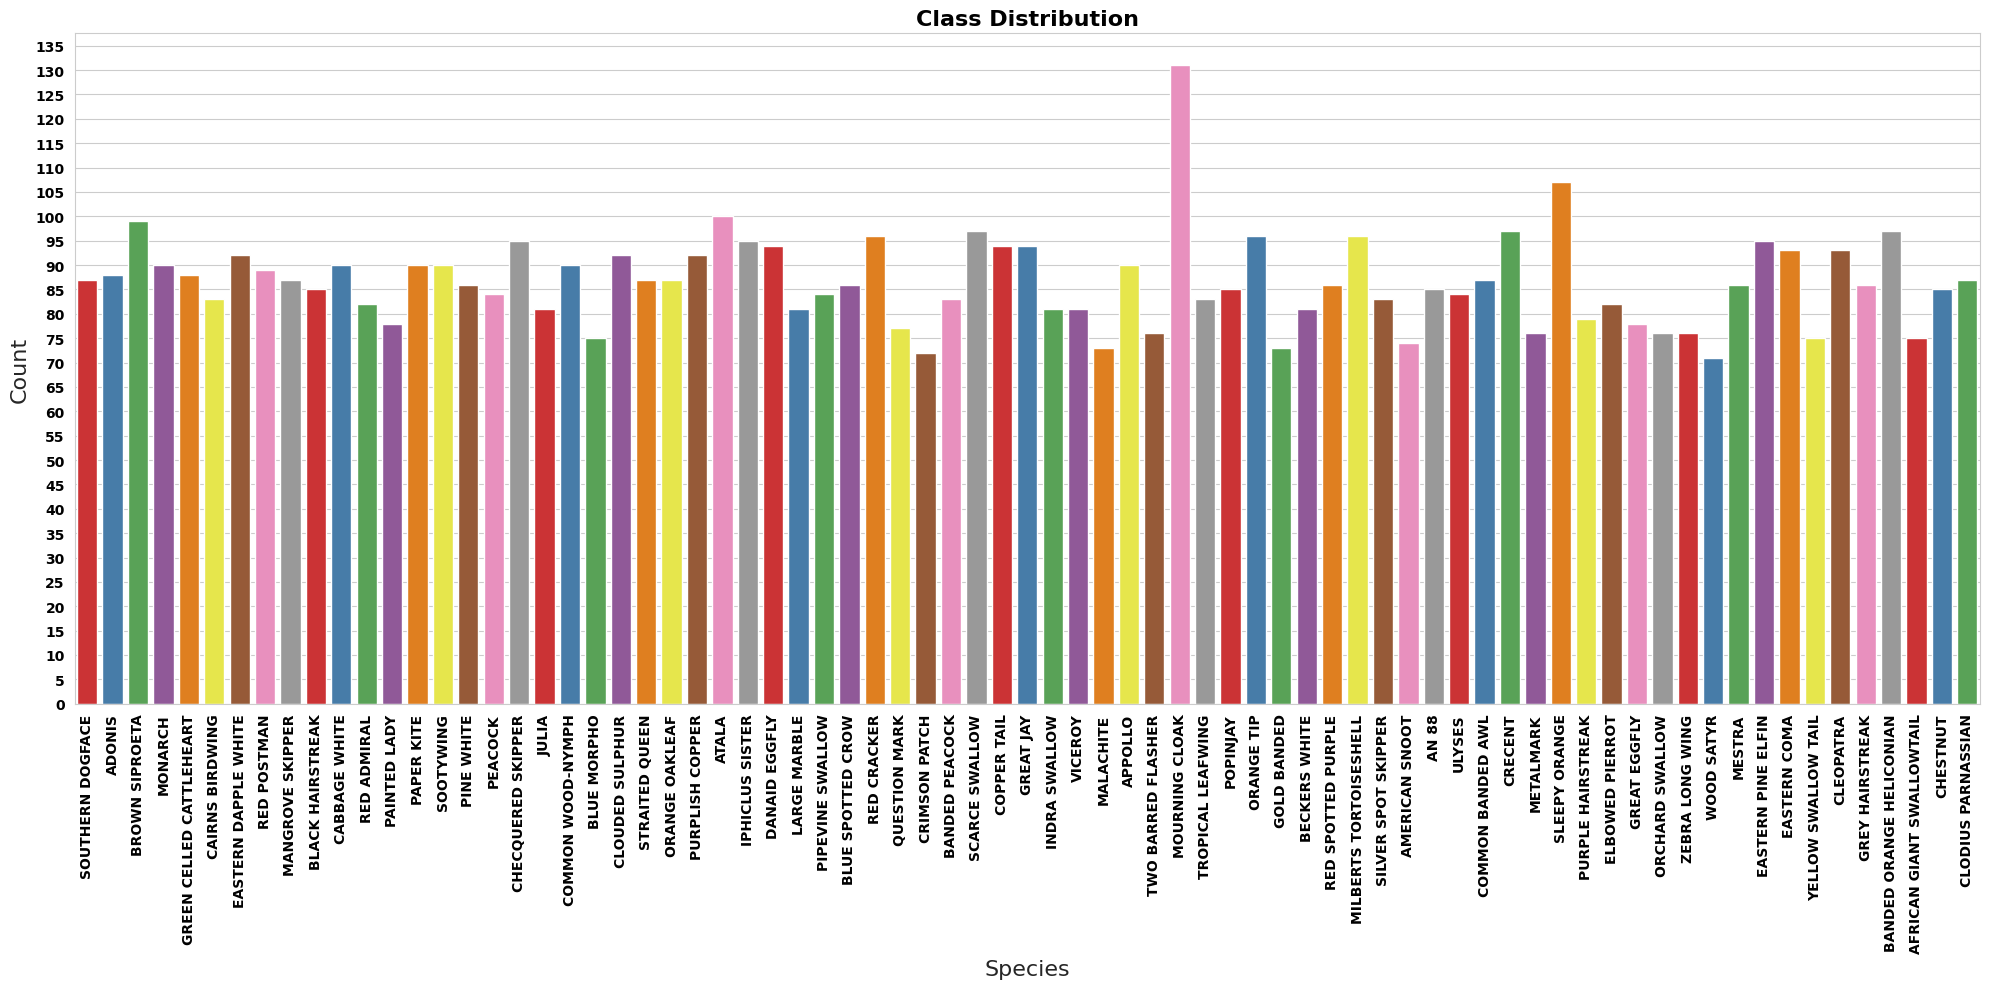

In [21]:
plt.figure(figsize=(20, 10))
sns.set_style('whitegrid')
sns.countplot(x=train_df['label'], palette='Set1')
plt.title("Class Distribution", fontsize=16, color="#000000", weight='bold')
plt.xlabel("Species", fontsize=16)
plt.ylabel("Count", fontsize=16)
plt.xticks(rotation=90, color="#000000", weight='bold')
plt.gca().yaxis.set_major_locator(MultipleLocator(5))
plt.yticks(color="#000000", weight='bold')
plt.savefig("/content/drive/MyDrive/Datasets/butterfly_classification_project/class_distribution.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [26]:
# Print the minimum and maximum class frequencies for label column
print(f"Minimum frequency: {train_df['label'].value_counts().min()}")
print(f"Maximum frequency: {train_df['label'].value_counts().max()}")

Minimum frequency: 71
Maximum frequency: 131


Sufficient images in each class; Ok for training

In [27]:
# Check for any missing images by verifying if the paths exist
missing_files = train_df[~train_df['image_path'].apply(os.path.exists)]
print("Missing Count:",len(missing_files))

Missing Count: 0


# Now Real EDA start

In [28]:
#File formate check
valid_ext = (".jpg", ".jpeg", ".png")
invalid_files = []

for path in train_df['image_path']:
    if not path.lower().endswith(valid_ext):
        invalid_files.append(path)

print("Invalid formate images:", len(invalid_files))

Invalid formate images: 0


In [29]:
#RGB/ corruted image check
#corrupted = []
#non_rgb = []

#for path in train_df['image_path']:
#    try:
#        img = Image.open(path)
#
        #check RGB
#        if img.mode != "RGB":
#            non_rgb.append(path)
#
#            img.verify()
#    except:
#        corrupted.append(path)

#print("Corrupted Images:", len(corrupted))
#print("Non RGB:", len(non_rgb))

In [30]:
#small size image checking
small_files = []
for path in train_df['image_path']:
    try:
        size_kb = os.path.getsize(path) / 1024
        if size_kb < 5:
            small_files.append(path)
    except:
        pass

print("Small Files (<5kb):", len(small_files))

Small Files (<5kb): 0


In [31]:
#checking diplicate images
train_files = set(train_df['filename'])

print("Total train images:", len(train_files))
print("unique images:", len(set(train_files)))

Total train images: 6499
unique images: 6499


# Preprocessing

In [32]:
lr = LabelEncoder()
train_df['encoded'] = lr.fit_transform(train_df['label'])

joblib.dump(lr, "/content/drive/MyDrive/Datasets/butterfly_classification_project/label_encoder.joblib")
print("Classes:", lr.classes_[:5])

Classes: ['ADONIS' 'AFRICAN GIANT SWALLOWTAIL' 'AMERICAN SNOOT' 'AN 88' 'APPOLLO']


In [33]:
#Train/Validation split
train_df, val_df = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df['encoded']
)
print("Train size", len(train_df))
print("Val size:", len(val_df))

Train size 5199
Val size: 1300


# Augmentation Layer

In [34]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1)
], name='augmentation')

In [35]:
#image loading
"""def load_image_96(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (96, 96))
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape((96, 96, 3))
    return img, label

def load_and_augment_96(image_path, label):
    img, label = load_image_96(image_path, label)
    img = augmentation(img, training=True)
    return img, label"""

'def load_image_96(image_path, label):\n    img = tf.io.read_file(image_path)\n    img = tf.image.decode_jpeg(img, channels=3)\n    img = tf.image.resize(img, (96, 96))\n    img = tf.cast(img, tf.float32) / 255.0\n    img.set_shape((96, 96, 3))\n    return img, label\n\ndef load_and_augment_96(image_path, label):\n    img, label = load_image_96(image_path, label)\n    img = augmentation(img, training=True)\n    return img, label'

In [36]:
#reusable function for augmentation & image loading 
def load_image_224(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape((224, 224, 3))
    return img, label

def load_and_augment_224(image_path, label):
    img, label = load_image_224(image_path, label)
    img = augmentation(img, training=True)
    return img, label

In [37]:
train_ds_cnn = (
    tf.data.Dataset.from_tensor_slices(
        (train_df['image_path'].values, train_df['encoded'].values)
    )
    .map(load_and_augment_224, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_cnn = (
    tf.data.Dataset.from_tensor_slices(
        (val_df['image_path'].values, val_df['encoded'].values)
    )
    .map(load_image_224, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)


In [38]:
test_ds = (
    tf.data.Dataset.from_tensor_slices(
        (test_df['image_path'].values)
    )
    .map(lambda p: load_image_224(p, 0)[0])
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

In [39]:
"""#training Pipeline
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df['image_path'].values, train_df['encoded'].values)
)

train_ds = train_ds.map(load_and_augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.batch(32)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = (
    tf.data.Dataset.from_tensor_slices(
        (val_df['image_path'].values, val_df['encoded'].values)
    )
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices(
        (test_df['image_path'].values)
    )
    .map(lambda p: load_image(p, 0)[0])
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)"""

"#training Pipeline\ntrain_ds = tf.data.Dataset.from_tensor_slices(\n    (train_df['image_path'].values, train_df['encoded'].values)\n)\n\ntrain_ds = train_ds.map(load_and_augment, num_parallel_calls=tf.data.AUTOTUNE)\ntrain_ds = train_ds.shuffle(1000)\ntrain_ds = train_ds.batch(32)\ntrain_ds = train_ds.prefetch(tf.data.AUTOTUNE)\n\nval_ds = (\n    tf.data.Dataset.from_tensor_slices(\n        (val_df['image_path'].values, val_df['encoded'].values)\n    )\n    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)\n    .batch(32)\n    .prefetch(tf.data.AUTOTUNE)\n)\n\ntest_ds = (\n    tf.data.Dataset.from_tensor_slices(\n        (test_df['image_path'].values)\n    )\n    .map(lambda p: load_image(p, 0)[0])\n    .batch(32)\n    .prefetch(tf.data.AUTOTUNE)\n)"

In [46]:
base_cnn_sequential = models.Sequential([
    layers.Input(shape=(224, 224, 3), name='input_layer'),

    #Block1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv1_1'),
    layers.BatchNormalization(name='bn1_1'),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv1_2'),
    layers.BatchNormalization(name='bn1_2'),
    layers.MaxPooling2D(2, 2, name='pool1'),

    #Block2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2_1'),
    layers.BatchNormalization(name='bn2_1'),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2_2'),
    layers.BatchNormalization(name='bn2_2'),
    layers.MaxPooling2D(2, 2, name='pool2'),

    #Block3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='conv3_1'),
    layers.BatchNormalization(name='bn3_1'),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='conv3_2'),
    layers.BatchNormalization(name='bn3_2'),
    layers.MaxPooling2D(2, 2, name='pool3'),

    #Block4
    layers.Conv2D(256, (3, 3), padding='same', activation='relu', name='conv4_1'),
    layers.BatchNormalization(name='bn4_1'),
    layers.MaxPooling2D(2, 2, name='pool4'),

    #Global Average layer
    layers.GlobalAveragePooling2D(name='global_average_pooling'),
    layers.Dense(512, activation='relu', name='dense_feature'),
    layers.BatchNormalization(name='dense_drop'),
    layers.Dropout(0.5, name='drop_out'),

    #outplut layer
    layers.Dense(75, activation='softmax', name='output_layer'),
], name='base_cnn_sequential')

In [47]:
base_cnn_sequential.summary()

Model: "base_cnn_sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_1 (Conv2D)                │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4_1 (BatchNormalization)      │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_feature (Dense)           │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_drop (BatchNormalization) │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_out (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 75)             │        38,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 757,099 (2.89 MB)

 Trainable params: 754,667 (2.88 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [31]:
base_cnn_sequential.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss= 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
base_cnn_sequential_callback = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7, 
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/Datasets/butterfly_classification_project/base_cnn_model.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.0000001,
        verbose=1
    )
]

In [33]:
base_cnn_model = base_cnn_sequential.fit(
    train_ds_cnn,
    validation_data = val_ds_cnn,
    epochs=20,
    callbacks = base_cnn_sequential_callback
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0150 - loss: 4.6293
Epoch 1: val_accuracy improved from None to 0.01462, saving model to /content/drive/MyDrive/Datasets/butterfly_classification_project/base_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Datasets/butterfly_classification_project/base_cnn_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 831s 4s/step - accuracy: 0.0137 - loss: 4.4807 - val_accuracy: 0.0146 - val_loss: 4.4133 - learning_rate: 3.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0160 - loss: 4.3457
Epoch 2: val_accuracy did not improve from 0.01462
163/163 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - accuracy: 0.0162 - loss: 4.3406 - val_accuracy: 0.0146 - val_loss: 4.3767 - learning_rate: 3.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0166 - loss: 4.3258
Epoch 3: val_accuracy did not improve from 0.01462
163/163 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.0154 - loss: 4.3263

In [ ]:
#MobileNetV2 as base model
base_model = MobileNetV2(
    weights= 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [30]:
base_model.trainable = False

In [31]:
total_classes = len(lr.classes_)
total_classes

75

In [32]:
model = models.Sequential([
    augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(total_classes, activation='softmax')
], name = "butterfly_classifier")

In [33]:
model.summary()

Model: "butterfly_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)
model.summary()

Model: "butterfly_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [35]:
#call back section
callback_1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3, 
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'butterfly_project/best_model_1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [36]:
history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks= callback_1
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.0120 - loss: 4.4575
Epoch 1: val_accuracy improved from None to 0.01846, saving model to butterfly_project/best_model_1.keras

Epoch 1: finished saving model to butterfly_project/best_model_1.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 938s 5s/step - accuracy: 0.0127 - loss: 4.3894 - val_accuracy: 0.0185 - val_loss: 4.3713 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0142 - loss: 4.3234
Epoch 2: val_accuracy did not improve from 0.01846
163/163 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.0144 - loss: 4.3206 - val_accuracy: 0.0185 - val_loss: 4.3262 - learning_rate: 1.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0149 - loss: 4.3125
Epoch 3: val_accuracy improved from 0.01846 to 0.02923, saving model to butterfly_project/best_model_1.keras

Epoch 3: finished saving model to butterfly_project/best_model_1.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step -